# TRABAJO FINAL BOOTCAMP CIENCIA DE DATOS
* ALUMNO :
* DATASET :[DATOS ABIERTOS](https://www.datosabiertos.gob.pe/dataset/cat%C3%A1logo-s%C3%ADsmico-1960-2023-instituto-geof%C3%ADsico-del-per%C3%BA-igp)

In [4]:
!pip install pyjanitor
import janitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 11.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
sns.set(style="whitegrid")

In [48]:
df = pd.read_csv('/content/sismoperu.csv')
df.head(5)

,ID,FECHA_UTC,HORA_UTC,LATITUD,LONGITUD,PROFUNDIDAD,MAGNITUD,FECHA_CORTE
0,0,19600113,154034,-16.145,-72.144,60,7.5,20223006
1,1,19600115,93024,-15.000,-75.000,70,7.0,20223006
2,2,19600117,25758,-14.500,-74.500,150,6.4,20223006
3,3,19600123,33732,-12.500,-68.500,300,5.8,20223006
4,4,19600130,50724,-5.500,-77.500,100,5.7,20223006


In [49]:
df = df.clean_names()
df

,id,fecha_utc,hora_utc,latitud,longitud,profundidad,magnitud,fecha_corte
0,0,19600113,154034,-16.145,-72.144,60,7.5,20223006
1,1,19600115,93024,-15.000,-75.000,70,7.0,20223006
2,2,19600117,25758,-14.500,-74.500,150,6.4,20223006
3,3,19600123,33732,-12.500,-68.500,300,5.8,20223006
4,4,19600130,50724,-5.500,-77.500,100,5.7,20223006
...,...,...,...,...,...,...,...,...
23675,23675,20231231,170836,-9.670,-75.630,125,4.0,20240101
23676,23676,20230223,61804,-8.690,-77.810,15,4.3,20240101
23677,23677,20230303,193913,-6.890,-80.230,43,4.3,20240101
23678,23678,20230327,201313,-10.530,-74.700,134,4.6,20240101


# EDA

In [45]:
df.dtypes

,0
id,int64
fecha_utc,int64
hora_utc,int64
latitud,float64
longitud,float64
profundidad,int64
magnitud,float64
fecha_corte,int64


In [29]:
df.isnull().sum().sum()

np.int64(0)

# CORRELACIÓN DE VARIABLES

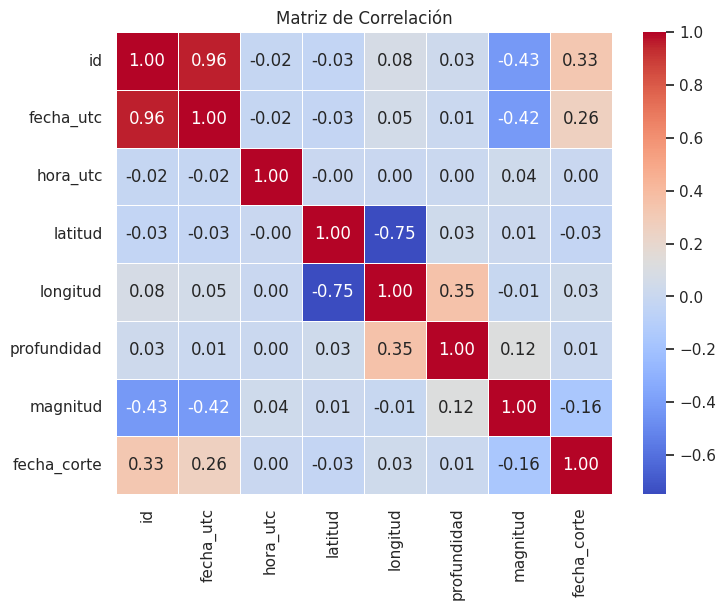

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

# CONVERTIMOS LA FECHA UTC

In [50]:
df_cleaned = df.copy()
df_cleaned["mes"] = df_cleaned["fecha_utc"].astype(str).str[4:6].astype(int)
#df_cleaned['hora'] = df_cleaned['fecha_utc'] // 1000
df_cleaned =  df_cleaned.drop(columns=['hora_utc','fecha_utc','id','fecha_corte'])
df_cleaned.head(10)

,latitud,longitud,profundidad,magnitud,mes
0,-16.145,-72.144,60,7.5,1
1,-15.000,-75.000,70,7.0,1
2,-14.500,-74.500,150,6.4,1
3,-12.500,-68.500,300,5.8,1
4,-5.500,-77.500,100,5.7,1
5,-8.500,-74.500,136,5.3,2
6,-17.500,-70.000,150,5.9,2
7,-16.389,-73.817,80,6.2,3
8,-14.500,-73.500,100,6.1,4
9,-18.000,-71.500,100,5.0,5


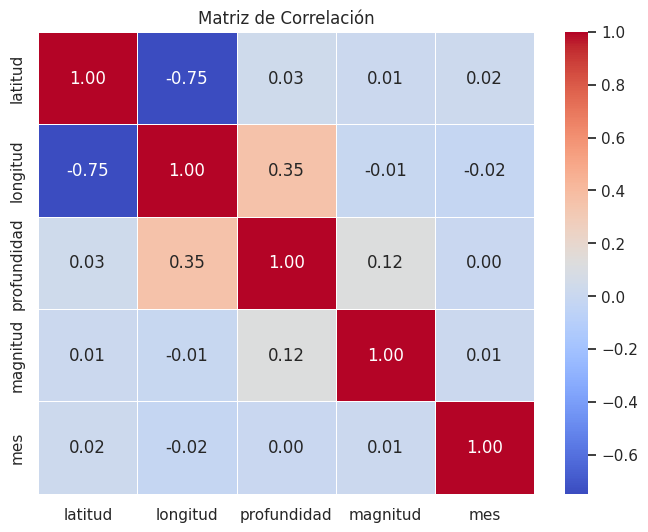

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

In [58]:
df_ubigeos = pd.read_csv('/content/TB_UBIGEOS.csv',delimiter=';')
df_ubigeos.columns

Index(['id_ubigeo', 'ubigeo_reniec', 'ubigeo_inei', 'departamento_inei',
       'departamento', 'provincia_inei', 'provincia', 'distrito', 'region',
       'macroregion_inei', 'macroregion_minsa', 'iso_3166_2', 'fips',
       'superficie', 'altitud', 'latitud', 'longitud', 'Frontera'],
      dtype='object')

In [59]:
df_ubigeos[df_ubigeos['departamento']=='AREQUIPA'][['provincia','distrito','latitud','longitud']]

,provincia,distrito,latitud,longitud
334,AREQUIPA,AREQUIPA,-16.3933,-71.5289
335,AREQUIPA,ALTO SELVA ALEGRE,-16.3800,-71.5211
336,AREQUIPA,CAYMA,-16.3625,-71.5442
337,AREQUIPA,CERRO COLORADO,-16.3764,-71.5608
338,AREQUIPA,CHARACATO,-16.4686,-71.4844
...,...,...,...,...
438,LA UNION,QUECHUALLA,-15.2739,-73.0222
439,LA UNION,SAYLA,-15.3200,-73.2219
440,LA UNION,TAURIA,-15.3542,-73.2325
441,LA UNION,TOMEPAMPA,-15.1731,-72.8303


In [60]:
from shapely.geometry import Point, Polygon
from geopy.distance import geodesic

centro = (-16.39889, -71.535)
radio_km = 50

# Crear un círculo con 360 puntos
num_puntos = 360
angulo = np.linspace(0, 360, num_puntos)

# Generar puntos alrededor del centro
puntos = [
    geodesic(kilometers=radio_km).destination(centro, ang)
    for ang in angulo
]

# Convertir a formato (lon, lat) para shapely
poligono_arequipa = Polygon([(p.longitude, p.latitude) for p in puntos])

def esta_dentro(lat, lon):
    punto = Point(lon, lat)
    return poligono_arequipa.contains(punto)

In [62]:
df_cleaned['arequipa'] = df.apply(lambda row : 1 if esta_dentro(row['latitud'],row['longitud']) else 0,axis=1)
df_cleaned[df_cleaned['arequipa']==1]

,latitud,longitud,profundidad,magnitud,mes,arequipa
167,-16.360,-71.620,116,6.2,1,1
222,-15.980,-71.600,136,5.3,7,1
322,-16.700,-71.400,97,4.6,8,1
468,-16.600,-71.800,144,4.5,9,1
1014,-16.098,-71.695,139,5.7,2,1
...,...,...,...,...,...,...
23064,-16.210,-71.760,126,4.0,10,1
23124,-16.120,-71.790,128,4.3,10,1
23368,-16.110,-71.670,150,4.0,5,1
23470,-16.120,-71.730,148,4.0,7,1
